# Analisis Sentimen Pilpres 2024: Perbandingan RNN, LSTM, dan GRU

| Nama                      | NPM        |
| ------------------------- | ---------- |
| Muhammad Hilmi Al Muttaqi | 2306267082 |
| Reyhan Ahnaf Deannova     | 2306267100 |
| Bryan Herdianto           | 2306210885 |
| Adhikananda Wira Januar   | 2306267113 |

Notebook ini membandingkan tiga arsitektur Recurrent Neural Network (**RNN**, **LSTM**, dan **GRU**) untuk mengklasifikasikan sentimen opini publik terkait Pemilihan Presiden Indonesia 2024.

Secara umum, alur kerjanya:

1. **Load Dataset**: mengunduh data tweet berlabel sentimen dari Kaggle
2. **Preprocessing**: membersihkan teks dari URL, mention, tanda baca, dll.
3. **Tokenisasi & Encoding**: mengubah teks menjadi angka agar bisa diproses model
4. **Bangun Model**: membuat tiga model (RNN, LSTM, GRU) dengan arsitektur yang setara
5. **Training**: melatih ketiga model dan menyimpan metriknya
6. **Evaluasi**: membandingkan akurasi, precision, recall, F1-score, dan waktu training
7. **Visualisasi**: menampilkan grafik loss/accuracy dan confusion matrix

In [1]:
import os
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import kagglehub

## 1. Load Dataset

Dataset diambil dari Kaggle dan berisi tweet yang sudah diberi label sentimen (**Positive**, **Negative**) untuk tiga pasangan calon presiden: Anies Baswedan, Ganjar Pranowo, dan Prabowo Subianto.

Kita akan mengunduh dataset, mencari file CSV-nya secara otomatis, lalu menggabungkan ketiga file menjadi satu dataframe.

In [2]:
print("Mengunduh dataset dari Kaggle...")
dataset_path = kagglehub.dataset_download("jocelyndumlao/indonesia-presidential-candidates-dataset-2024")
print(f"Dataset root folder: {dataset_path}")

path_anies = None
path_ganjar = None
path_prabowo = None

for root, dirs, files in os.walk(dataset_path):
    if 'labeled' in root.lower():
        for file in files:
            if "Anies Baswedan" in file and file.endswith('.csv'):
                path_anies = os.path.join(root, file)
            elif "Ganjar Pranowo" in file and file.endswith('.csv'):
                path_ganjar = os.path.join(root, file)
            elif "Prabowo Subianto" in file and file.endswith('.csv'):
                path_prabowo = os.path.join(root, file)

if not all([path_anies, path_ganjar, path_prabowo]):
    raise FileNotFoundError("Salah satu atau semua file CSV tidak ditemukan!")

print("\nBerhasil menemukan file:")
print(f"- {path_anies}")
print(f"- {path_ganjar}")
print(f"- {path_prabowo}")

Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'indonesia-presidential-candidates-dataset-2024' dataset.
Dataset root folder: /kaggle/input/indonesia-presidential-candidates-dataset-2024

Berhasil menemukan file:
- /kaggle/input/indonesia-presidential-candidates-dataset-2024/Indonesia Presidential Candidates Dataset, 2024/labeled data/Anies Baswedan.csv
- /kaggle/input/indonesia-presidential-candidates-dataset-2024/Indonesia Presidential Candidates Dataset, 2024/labeled data/Ganjar Pranowo.csv
- /kaggle/input/indonesia-presidential-candidates-dataset-2024/Indonesia Presidential Candidates Dataset, 2024/labeled data/Prabowo Subianto.csv


In [3]:
df_anies = pd.read_csv(path_anies)
df_ganjar = pd.read_csv(path_ganjar)
df_prabowo = pd.read_csv(path_prabowo)
df = pd.concat([df_anies, df_ganjar, df_prabowo], ignore_index=True)
df = df.dropna(subset=['Text', 'label'])

print(f"Total data bersih siap diproses: {df.shape[0]} baris")
print("\nDistribusi kelas:")
print(df['label'].value_counts())

Total data bersih siap diproses: 29728 baris

Distribusi kelas:
label
Positive    21654
Negative     8074
Name: count, dtype: int64


## 2. Text Preprocessing

Sebelum teks bisa diproses oleh model, kita perlu membersihkannya terlebih dahulu. Langkah-langkah pembersihan yang dilakukan:
- **Case folding**: mengubah semua huruf menjadi huruf kecil
- **Hapus URL**: menghilangkan link yang ada di tweet
- **Hapus mention dan hashtag**: menghilangkan `@username` dan `#tag`
- **Hapus tanda baca dan angka**: hanya menyisakan huruf dan spasi
- **Strip**: menghapus spasi berlebih di awal dan akhir teks

Teks yang bersih akan membantu model belajar pola sentimen dengan lebih baik.

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.strip()
    return text

df['cleaned_text'] = df['Text'].apply(clean_text)
print("Text preprocessing selesai.")
print(f"Contoh teks asli : {df['Text'].iloc[0]}")
print(f"Contoh teks bersih: {df['cleaned_text'].iloc[0]}")

Text preprocessing selesai.
Contoh teks asli : anies president info
Contoh teks bersih: anies president info


## 3. Tokenisasi & Label Encoding

Model tidak bisa memproses teks mentah, jadi kita perlu mengubahnya menjadi angka:
- **Tokenisasi**: setiap kata diubah menjadi indeks angka berdasarkan kamus yang dibangun dari data. Kita membatasi kamusnya sebanyak 10.000 kata (`max_words`) dan panjang kalimat maksimal 100 kata (`max_len`).
- **Padding**: menyamakan panjang semua kalimat agar seragam (kalimat pendek ditambah nol, kalimat panjang dipotong).
- **Label Encoding**: mengubah label sentimen (Positive/Negative) menjadi angka (0/1).
- **Class Weight**: karena jumlah data per kelas tidak seimbang, kita hitung bobot kelas agar model tidak cenderung memihak kelas mayoritas.

Data dibagi menjadi **80% training** dan **20% testing**.

In [5]:
le = LabelEncoder()
y = le.fit_transform(df['label'])
num_classes = len(np.unique(y))
target_names = le.classes_

print(f"Label classes: {list(enumerate(target_names))}")
print(f"Jumlah kelas: {num_classes}")

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_text'])

X = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Shape X: {X.shape}, Shape y: {y.shape}")

Label classes: [(0, 'Negative'), (1, 'Positive')]
Jumlah kelas: 2
Vocabulary size: 17612
Shape X: (29728, 100), Shape y: (29728,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

print(f"Training set: {X_train.shape[0]} sampel")
print(f"Testing set : {X_test.shape[0]} sampel")

class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(class_weights_arr))
print("\nClass weights (untuk mengatasi imbalance):")
for k, v in class_weight.items():
    print(f"  Kelas {k} ({target_names[k]}): {v:.4f}")

Training set: 23782 sampel
Testing set : 5946 sampel

Class weights (untuk mengatasi imbalance):
  Kelas 0 (Negative): 1.8410
  Kelas 1 (Positive): 0.6864


## 4. Bangun Model

Kita membangun tiga model dengan arsitektur yang setara agar perbandingannya adil:

| Komponen | Keterangan |
|---|---|
| **Embedding** | Mengubah kata (indeks angka) menjadi vektor 128 dimensi |
| **Recurrent Layer** | Simple RNN / Bidirectional LSTM / Bidirectional GRU dengan 128 unit |
| **Dense** | Layer fully-connected 64 neuron dengan aktivasi ReLU + Dropout 0.3 |
| **Output** | Softmax dengan jumlah neuron = jumlah kelas sentimen |

> **Kenapa Bidirectional untuk LSTM dan GRU?** Bidirectional membaca teks dari kiri-ke-kanan **dan** kanan-ke-kiri, sehingga model bisa menangkap konteks dari kedua arah. Simple RNN tetap menggunakan arsitektur satu arah sebagai baseline.

> **Kenapa pakai class_weight?** Karena jumlah data per kelas tidak seimbang, class_weight memberikan bobot lebih besar pada kelas yang sedikit datanya agar model tidak hanya memprediksi kelas mayoritas.

### Hyperparameter Tuning

Sebelum melatih model final, kita melakukan eksplorasi ruang hyperparameter pada **subset 10% data training** untuk menemukan konfigurasi yang menjanjikan. Pendekatan ini mengurangi waktu komputasi secara drastis dibanding tuning pada full dataset.

Ruang pencarian (search space):
- **Dimensi Embedding** (`embedding_dim`): [64, 128, 256]
- **Jumlah Hidden Units** (`units`): [64, 128, 256]
- **Tingkat Regularisasi** (`dropout`): [0.2, 0.3, 0.5]
- **Learning Rate** (`learning_rate`): [0.001, 0.0005] menggunakan optimizer Adam

Kita gunakan **random search** dengan 8 kombinasi pada model LSTM (model utama).

In [ ]:
def build_tunable_model(units, dropout, embedding_dim, learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=embedding_dim))
    model.add(Bidirectional(LSTM(units, dropout=dropout, recurrent_dropout=max(0.0, dropout - 0.1))))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Ambil subset 10% dari data training untuk tuning cepat
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train, train_size=0.1, random_state=10, stratify=y_train
)
print(f'Subset tuning: {X_train_sub.shape[0]} sampel ({X_train_sub.shape[0]/X_train.shape[0]*100:.1f}% dari training data)')

param_grid = {
    'units': [64, 128, 256],
    'dropout': [0.2, 0.3, 0.5],
    'embedding_dim': [64, 128, 256],
    'learning_rate': [0.001, 0.0005]
}

np.random.seed(10)
n_trials = 8
tuning_results = []

for trial in range(n_trials):
    units = int(np.random.choice(param_grid['units']))
    dropout = float(np.random.choice(param_grid['dropout']))
    embedding_dim = int(np.random.choice(param_grid['embedding_dim']))
    learning_rate = float(np.random.choice(param_grid['learning_rate']))

    print(f"\n--- Trial {trial+1}/{n_trials} ---")
    print(f"units={units}, dropout={dropout}, emb_dim={embedding_dim}, lr={learning_rate}")

    model = build_tunable_model(units, dropout, embedding_dim, learning_rate)
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=0)

    start = time.time()
    history = model.fit(
        X_train_sub, y_train_sub,
        epochs=5,
        batch_size=64,
        validation_split=0.1,
        class_weight=class_weight,
        callbacks=[es],
        verbose=0
    )
    elapsed = time.time() - start

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    tuning_results.append({
        'Trial': trial + 1,
        'Units': units,
        'Dropout': dropout,
        'Embedding Dim': embedding_dim,
        'Learning Rate': learning_rate,
        'Epochs': len(history.history['loss']),
        'Accuracy': acc,
        'F1-Score': f1,
        'Time (s)': elapsed
    })

    print(f"Accuracy: {acc:.4f}, F1-Score: {f1:.4f}, Epochs: {len(history.history['loss'])}, Time: {elapsed:.1f}s")

tuning_df = pd.DataFrame(tuning_results)
print("\nHASIL HYPERPARAMETER TUNING (10% Data)")
print("=" * 70)
print(tuning_df.round(4).to_string(index=False))

best_cfg = tuning_df.loc[tuning_df['F1-Score'].idxmax()]
print(f"\nKonfigurasi Terbaik -> Trial {int(best_cfg['Trial'])}: units={int(best_cfg['Units'])}, dropout={best_cfg['Dropout']}, emb={int(best_cfg['Embedding Dim'])}, lr={best_cfg['Learning Rate']}")
print(f"F1-Score: {best_cfg['F1-Score']:.4f} | Accuracy: {best_cfg['Accuracy']:.4f}")

In [7]:
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128))

    if model_type == 'Simple RNN':
        model.add(SimpleRNN(128, dropout=0.3, recurrent_dropout=0.2))
    elif model_type == 'LSTM':
        model.add(Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.2)))
    elif model_type == 'GRU':
        model.add(Bidirectional(GRU(128, dropout=0.3, recurrent_dropout=0.2)))

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

## 5. Training Model

Ketiga model dilatih dengan konfigurasi yang sama:
- **Epoch** = 10 (maksimal), dengan **EarlyStopping** patience=2 (berhenti jika val_loss tidak membaik selama 2 epoch)
- **Batch size** = 64
- **Validation split** = 10% dari data training
- **Class weight** diterapkan agar model memperhatikan kelas minoritas

Setelah training, model diuji pada data testing dan metrik berikut dihitung: Accuracy, Precision, Recall, F1-Score.

In [8]:
models_to_train = ['Simple RNN', 'LSTM', 'GRU']
results = {}
histories = {}
trained_models = {}

epochs = 10
batch_size = 64
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

for model_name in models_to_train:
    print(f"\nTraining Model: {model_name}")
    print("-" * 40)

    model = build_model(model_name)
    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=1
    )

    training_time = time.time() - start_time
    histories[model_name] = history
    trained_models[model_name] = model

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results[model_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'Confusion Matrix': cm
    }

    print(f"Selesai! Accuracy: {acc:.4f}, F1-Score: {f1:.4f}, Waktu: {training_time:.1f}s")


Training Model: Simple RNN
----------------------------------------
Epoch 1/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.4795 - loss: 0.7045 - val_accuracy: 0.7343 - val_loss: 0.6737
Epoch 2/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4925 - loss: 0.7055 - val_accuracy: 0.5914 - val_loss: 0.7148
Epoch 3/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4841 - loss: 0.6995 - val_accuracy: 0.2657 - val_loss: 0.7029
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Selesai! Accuracy: 0.7284, F1-Score: 0.6139, Waktu: 21.8s

Training Model: LSTM
----------------------------------------
Epoch 1/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 258s 731ms/step - accuracy: 0.7920 - loss: 0.4547 - val_accuracy: 0.8823 - val_loss: 0.3147
Epoch 2/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 230s 687ms/step - accuracy: 0.9023 - loss: 0.2678 - val_accuracy: 0.8995 - val_loss: 0.2615
Epoch 3/10
335/335 ━━━━━━━━━━━━━━━

## 6. Tabel Perbandingan Performa

Berikut adalah perbandingan metrik kinerja ketiga model. Semakin tinggi nilai Accuracy, Precision, Recall, dan F1-Score, semakin baik performa model tersebut.

In [9]:
print("PERBANDINGAN KINERJA MODEL")
print("=" * 60)
results_df = pd.DataFrame(results).T
display_df = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)']]
print(display_df.round(4).to_string())

PERBANDINGAN KINERJA MODEL
            Accuracy Precision    Recall  F1-Score Training Time (s)
Simple RNN  0.728389   0.53055  0.728389  0.613925         21.839069
LSTM        0.888833  0.894358  0.888833  0.890631        980.282315
GRU         0.871174  0.878069  0.871174  0.873466        414.716151


## 7. Visualisasi Hasil Training

### Grafik Akurasi & Loss per Epoch

Grafik di bawah menunjukkan perbandingan **akurasi validasi** dan **loss validasi** ketiga model di setiap epoch. Model yang baik memiliki akurasi yang naik dan loss yang turun secara konsisten.

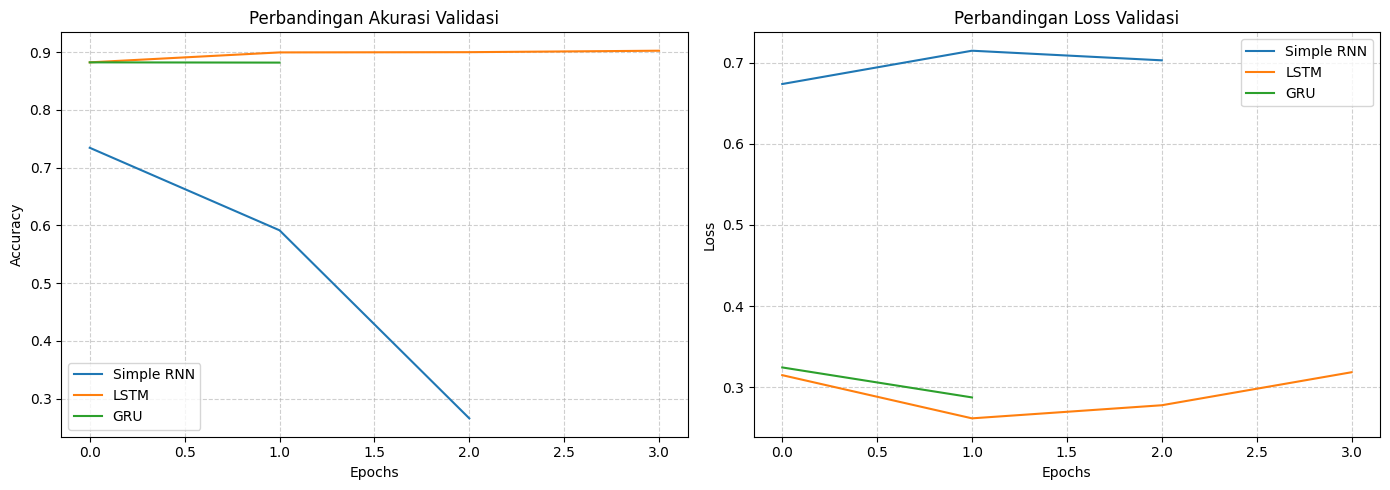

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, history in histories.items():
    axes[0].plot(history.history['val_accuracy'], label=f'{model_name}')
    axes[1].plot(history.history['val_loss'], label=f'{model_name}')

axes[0].set_title('Perbandingan Akurasi Validasi')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Perbandingan Loss Validasi')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Confusion Matrix

Confusion matrix menunjukkan distribusi prediksi model terhadap label aktual. Diagonal utama menunjukkan jumlah prediksi yang benar, sedangkan sel lainnya menunjukkan kesalahan prediksi.

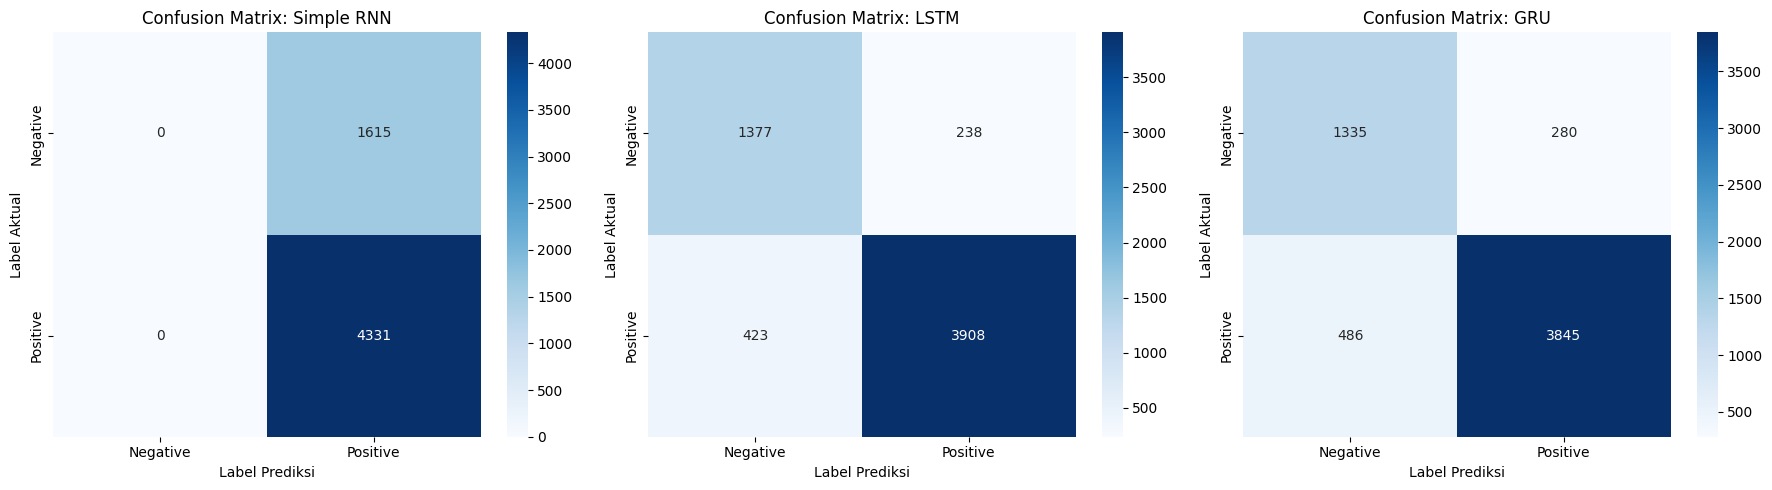

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, model_name in enumerate(models_to_train):
    sns.heatmap(results[model_name]['Confusion Matrix'],
                annot=True, fmt='d', cmap='Blues',
                ax=axes[i], xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(f'Confusion Matrix: {model_name}')
    axes[i].set_xlabel('Label Prediksi')
    axes[i].set_ylabel('Label Aktual')

plt.tight_layout()
plt.show()

## 8. Analisis Etika & Keterbatasan

Bagian ini menganalisis potensi bias pada model, identifikasi kasus kegagalan (edge cases), serta keterbatasan yang perlu diperhatikan dalam penggunaan model ini.

### 8.1 Analisis Bias per Kandidat

Dataset menggabungkan tweet dari tiga kandidat (Anies, Ganjar, Prabowo). Jika distribusi sentimen antar kandidat tidak seimbang, model bisa memiliki bias terhadap kandidat tertentu. Mari kita analisis.

Distribusi Sentimen per Kandidat:
label             Negative  Positive
kandidat                            
Anies Baswedan       35.01     64.99
Ganjar Pranowo       20.78     79.22
Prabowo Subianto     25.66     74.34


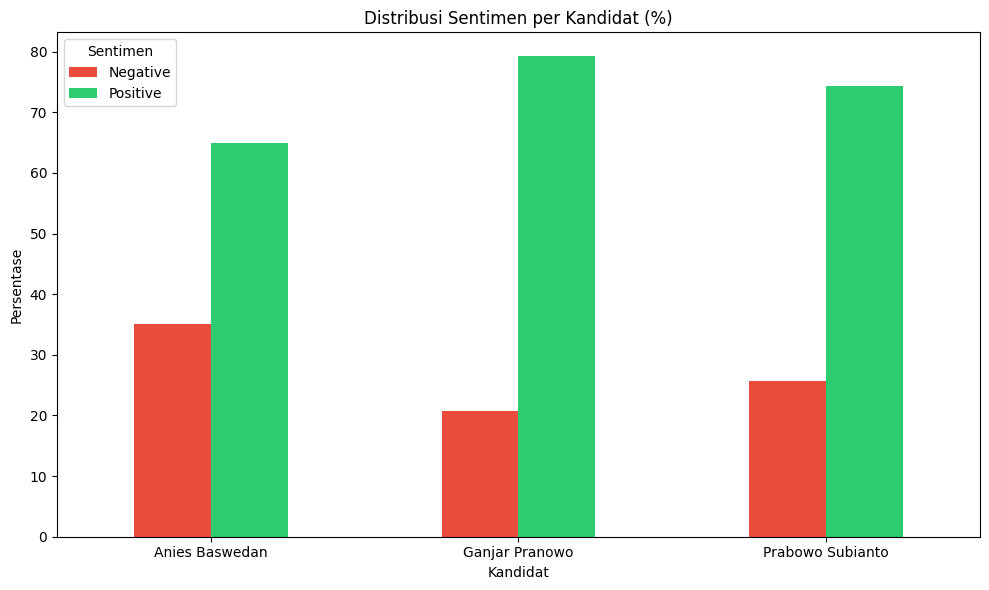


Analisis Bias:
- Anies Baswedan: didominasi sentimen Positive (65.0%)
- Ganjar Pranowo: didominasi sentimen Positive (79.2%)
- Prabowo Subianto: didominasi sentimen Positive (74.3%)


In [12]:
# Identifikasi kandidat berdasarkan dataframe asli
df_anies_clean = df_anies.dropna(subset=['Text', 'label']).copy()
df_ganjar_clean = df_ganjar.dropna(subset=['Text', 'label']).copy()
df_prabowo_clean = df_prabowo.dropna(subset=['Text', 'label']).copy()

df_anies_clean['kandidat'] = 'Anies Baswedan'
df_ganjar_clean['kandidat'] = 'Ganjar Pranowo'
df_prabowo_clean['kandidat'] = 'Prabowo Subianto'

df_all = pd.concat([df_anies_clean, df_ganjar_clean, df_prabowo_clean], ignore_index=True)

print("Distribusi Sentimen per Kandidat:")
distribusi_kandidat = pd.crosstab(df_all['kandidat'], df_all['label'], normalize='index') * 100
print(distribusi_kandidat.round(2))

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
distribusi_kandidat.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71', '#3498db'])
ax.set_title('Distribusi Sentimen per Kandidat (%)')
ax.set_ylabel('Persentase')
ax.set_xlabel('Kandidat')
ax.legend(title='Sentimen')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Identifikasi bias
print("\nAnalisis Bias:")
for kandidat in distribusi_kandidat.index:
    max_sentimen = distribusi_kandidat.loc[kandidat].idxmax()
    max_val = distribusi_kandidat.loc[kandidat].max()
    print(f"- {kandidat}: didominasi sentimen {max_sentimen} ({max_val:.1f}%)")

### 8.2 Identifikasi Kasus Kegagalan (Edge Cases)

Mari kita analisis sampel-sampel yang salah diprediksi oleh model terbaik untuk memahami pola kegagalan.

In [13]:
# Gunakan model baseline terbaik yang sudah ditrain (LSTM/GRU)
best_base_model = 'LSTM' if results['LSTM']['F1-Score'] >= results['GRU']['F1-Score'] else 'GRU'
best_model_obj = trained_models[best_base_model]
print(f'Model terpilih untuk analisis error: {best_base_model}')
print(f'F1-Score: {results[best_base_model]["F1-Score"]:.4f}')

y_pred_prob_best = best_model_obj.predict(X_test, verbose=0)
y_pred_best = np.argmax(y_pred_prob_best, axis=1)

# Identifikasi indeks yang salah prediksi
error_indices = np.where(y_pred_best != y_test)[0]
print(f"Total sampel testing: {len(y_test)}")
print(f"Jumlah prediksi salah: {len(error_indices)} ({len(error_indices)/len(y_test)*100:.2f}%)")

# Mapping ke teks asli
test_indices = X_test.shape[0]
# Gunakan train_test_split indices untuk mendapatkan teks asli
_, test_idx = train_test_split(range(len(df)), test_size=0.2, random_state=10, stratify=y)

error_samples = []
for idx in error_indices[:20]:  # Ambil 20 error pertama
    original_idx = test_idx[idx]
    true_label = target_names[y_test[idx]]
    pred_label = target_names[y_pred_best[idx]]
    confidence = np.max(y_pred_prob_best[idx])
    text = df.iloc[original_idx]['Text']
    cleaned = df.iloc[original_idx]['cleaned_text']
    error_samples.append({
        'Teks Asli': text[:100] + '...' if len(text) > 100 else text,
        'Teks Bersih': cleaned[:100] + '...' if len(cleaned) > 100 else cleaned,
        'Label Aktual': true_label,
        'Label Prediksi': pred_label,
        'Confidence': confidence
    })

error_df = pd.DataFrame(error_samples)
print("\nContoh Kasus Kegagalan Prediksi:")
print("=" * 80)
for _, row in error_df.head(10).iterrows():
    print(f"Teks: {row['Teks Asli']}")
    print(f"Aktual: {row['Label Aktual']} | Prediksi: {row['Label Prediksi']} (conf: {row['Confidence']:.3f})")
    print("-" * 80)

Model terpilih untuk analisis error: LSTM
F1-Score: 0.8906
Total sampel testing: 5946
Jumlah prediksi salah: 661 (11.12%)

Contoh Kasus Kegagalan Prediksi:
Teks: indonesia's year of president ganjar pranowo vice president erick thohir bookmarks now retweet anoth...
Aktual: Negative | Prediksi: Positive (conf: 0.924)
--------------------------------------------------------------------------------
Teks: based on voting from participants who participated in the poll at musra central java, the governor o...
Aktual: Positive | Prediksi: Negative (conf: 0.891)
--------------------------------------------------------------------------------
Teks: inismyname the problem is that there is fadlizon. if you fire mr. fadlizon, indonesian citizens will...
Aktual: Negative | Prediksi: Positive (conf: 0.660)
--------------------------------------------------------------------------------
Teks: indeed, mr ganjar deserves to be an idol. continue to support him. follow us for other information. ...
Aktua

### 8.3 Analisis Pola Error per Kelas

Analisis confusion matrix secara mendalam untuk memahami kelas mana yang paling sering tertukar.

Classification Report (Model Terbaik):
              precision    recall  f1-score   support

    Negative       0.77      0.85      0.81      1615
    Positive       0.94      0.90      0.92      4331

    accuracy                           0.89      5946
   macro avg       0.85      0.88      0.86      5946
weighted avg       0.89      0.89      0.89      5946


Analisis Error per Kelas:
- Negative: 1377/1615 benar (error rate: 14.7%)
- Positive: 3908/4331 benar (error rate: 9.8%)


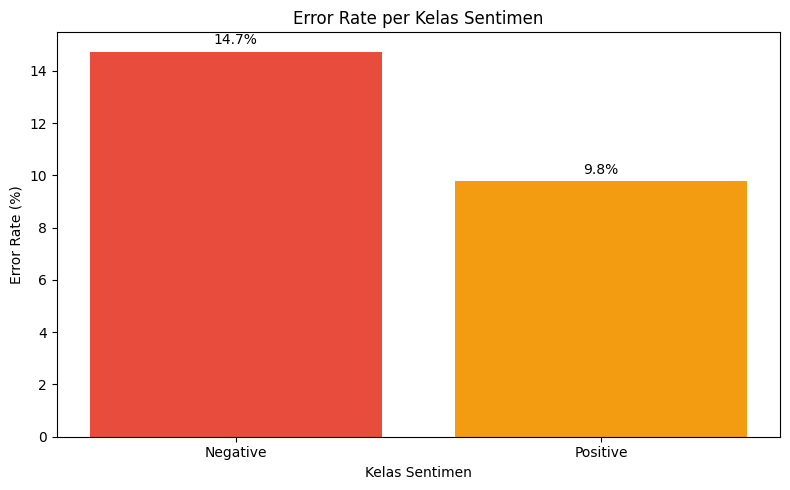

In [14]:
print("Classification Report (Model Terbaik):")
print(classification_report(y_test, y_pred_best, target_names=target_names, zero_division=0))

# Analisis per kelas dari confusion matrix
cm_best = confusion_matrix(y_test, y_pred_best)
print("\nAnalisis Error per Kelas:")
for i, class_name in enumerate(target_names):
    total = cm_best[i].sum()
    correct = cm_best[i, i]
    error_rate = (total - correct) / total * 100 if total > 0 else 0
    print(f"- {class_name}: {correct}/{total} benar (error rate: {error_rate:.1f}%)")

# Visualisasi error rate
error_rates = []
for i, class_name in enumerate(target_names):
    total = cm_best[i].sum()
    correct = cm_best[i, i]
    error_rate = (total - correct) / total * 100 if total > 0 else 0
    error_rates.append(error_rate)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(target_names, error_rates, color=['#e74c3c', '#f39c12', '#3498db'][:len(target_names)])
ax.set_title('Error Rate per Kelas Sentimen')
ax.set_ylabel('Error Rate (%)')
ax.set_xlabel('Kelas Sentimen')
for bar, rate in zip(bars, error_rates):
    height = bar.get_height()
    ax.annotate(f'{rate:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.tight_layout()
plt.show()

### 8.4 Keterbatasan Model & Implikasi Etis

Berikut adalah analisis kritis mengenai keterbatasan dan implikasi etis penggunaan model ini:

**1. Keterbatasan Data & Preprocessing**
- **Hapus hashtag dan mention**: Informasi kontekstual penting seringkali terkandung dalam hashtag (misal: #DebatCapres). Penghapusan menyebabkan kehilangan konteks.
- **Case folding**: Penulisan huruf kapital dalam bahasa Indonesia sering digunakan untuk penekanan emosi (misal: "SANGAT KECEWA"). Mengubah ke lowercase menghilangkan sinyal ini.
- **Tidak ada handling sarcasm/ironi**: Model RNN/LSTM standar sulit mendeteksi sarkasme yang sangat umum di media sosial.
- **OOV (Out-of-Vocabulary)**: Kata-kata slang, typo, atau bahasa daerah tidak ada di vocabulary (diubah menjadi `<OOV>`), mengurangi akurasi.

**2. Potensi Bias**
- **Bias kandidat**: Jika dataset per kandidat memiliki distribusi sentimen yang sangat berbeda, model mungkin belajar bias politik tertentu.
- **Bias bahasa**: Model hanya dilatih pada teks Indonesia. Campuran bahasa (Indonesia-Inggris) atau bahasa daerah tidak ditangani dengan baik.
- **Bias temporal**: Data berasal dari periode tertentu (kampanye Pilpres 2024). Sentimen dapat berubah drastis setelah periode tersebut.

**3. Edge Cases yang Perlu Diwaspadai**
- **Teks sangat pendek**: Tweet dengan 1-2 kata (misal: "mantap", "gak setuju") sulit diklasifikasikan karena kurangnya konteks.
- **Teks ambigu**: Kalimat netral yang mengandung kata-kata positif/negatif (misal: "saya tidak suka tapi saya menghargai").
- **Teks provokatif/bukan opini**: Tweet yang berisi hoaks atau provokasi bukanlah ekspresi sentimen genuine, tapi model tetap akan mengklasifikasikannya.
- **Akun bot/spam**: Jika dataset mengandung tweet dari akun bot, model belajar dari data yang tidak merepresentasikan opini manusia asli.

**4. Implikasi Etis Penggunaan**
- **Representasi publik yang tidak adil**: Model ini tidak boleh digunakan sebagai dasar kebijakan tanpa validasi manual karena tingkat error yang masih signifikan.
- **Privasi**: Meskipun data publik, penggunaan sentimen analisis untuk profiling individu tanpa consent bermasalah secara etis.
- **Amplifikasi bias**: Jika digunakan untuk memantau opini publik secara otomatis, model bisa memperkuat bias yang sudah ada dalam dataset.
- **Akuntabilitas**: Kesalahan klasifikasi pada level individu dapat merugikan reputasi seseorang.

**Rekomendasi**
- Gunakan model ini hanya untuk analisis agregat (tren besar), bukan untuk keputusan individual.
- Lakukan validasi manual secara berkala pada subset hasil prediksi.
- Jelaskan keterbatasan model saat menyajikan hasil kepada stakeholder.
- Pertimbangkan augmentasi data untuk kelas minoritas dan handling bahasa lebih baik.

## Ringkasan

Cell di bawah ini akan menampilkan ringkasan distribusi kelas dan metrik performa model jika cell-cell sebelumnya sudah dijalankan.

In [15]:
try:
    print('Distribusi Kelas:')
    print(df['label'].value_counts())
    print('\nRingkasan Metrik:')
    display(display_df)
except NameError as e:
    print(f"Error: {e}")
    print("Jalankan semua cell di atas terlebih dahulu.")

Distribusi Kelas:
label
Positive    21654
Negative     8074
Name: count, dtype: int64

Ringkasan Metrik:


,Accuracy,Precision,Recall,F1-Score,Training Time (s)
Simple RNN,0.728389,0.53055,0.728389,0.613925,21.839069
LSTM,0.888833,0.894358,0.888833,0.890631,980.282315
GRU,0.871174,0.878069,0.871174,0.873466,414.716151
